In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from vis import make_yref, load_border_vertices_xml
# from sklearn.preprocessing import StandardScaler
from util import concat_hrf, group_by_dict_fields
from sklearn.preprocessing import MinMaxScaler
import os
import globals as gl
from pcm_models import find_model, make_planning_models, make_execution_models
import PcmPy as pcm
from scipy.stats import linregress, t, permutation_test
from statsmodels.stats.anova import AnovaRM
from nilearn import surface
import pickle
import pingouin as pg
from matplotlib import colormaps as cm
from scipy.stats import ttest_1samp, pearsonr, ttest_rel
from matplotlib.patches import ConnectionPatch, Rectangle, Patch
from matplotlib.lines import Line2D
import os
import globals as gl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import pandas as pd
import seaborn as sb
import nibabel as nb
import numpy as np
import nitools as nt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import pyvista as pv
from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_1samp

import nitools as nt

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


In [2]:
experiment = 'smp2'

In [5]:
from vis import demographics
_ = demographics(experiment)

Total Participants: 14
Gender Distribution: sex
m    8
f    6
Name: count, dtype: int64
Average Age: 21.357142857142858
SD Age: 4.162232072359232
Age Range: (np.int64(18), np.int64(34))
Handedness Distribution: handedness
right    14
Name: count, dtype: int64


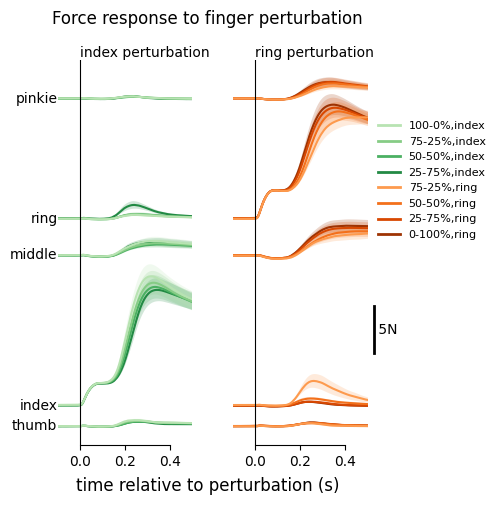

In [5]:
from vis import plot_force_aligned

npz = np.load(os.path.join(gl.baseDir, experiment, gl.behavDir, 'force.segmented.avg.npz'), allow_pickle=True)
force = npz['data_array']
descr = pd.DataFrame(npz['descriptor'].item())
force = force[descr.GoNogo == 'go']
descr = descr[descr.GoNogo == 'go']
fig, axs = plt.subplots(1, 2, figsize=(4, 5), sharey=True, sharex=True)
plot_force_aligned(fig, axs, force, descr)
plt.show()

rmANOVA index
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue 20.7316 3.0000 39.0000 0.0000

rmANOVA ring
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  7.4148 3.0000 39.0000 0.0005



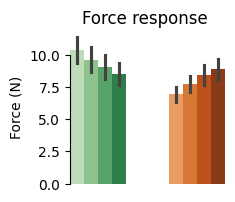

In [6]:
from vis import plot_force_binned

fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
filepath = os.path.join(gl.baseDir, experiment, gl.behavDir, f'{experiment}_force_single_trial.tsv')
dat = pd.read_csv(filepath, sep='\t', )
dat = dat.groupby(['sn', 'cue', 'stimFinger', 'GoNogo', ]).mean(numeric_only=True).reset_index()
fig, axs = plot_force_binned(fig, axs, dat, y=['index1', 'ring1'], finger=('index', 'ring'))
axs[0].spines[['left']].set_bounds(0, 10)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Force response')

anova_index = AnovaRM(data=dat[dat['stimFinger']=='index'], depvar='index1', subject='sn', within=['cue'])
anova_ring = AnovaRM(data=dat[dat['stimFinger']=='ring'], depvar='ring1', subject='sn', within=['cue'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

plt.show()

rmANOVA index
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  3.4133 4.0000 52.0000 0.0149

rmANOVA ring
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  6.0417 4.0000 52.0000 0.0005



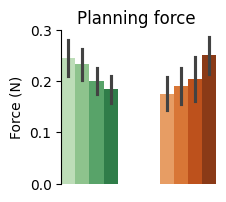

In [8]:
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
fig, axs = plot_force_binned(fig, axs, dat, y=['index0', 'ring0'])
axs[0].spines[['left']].set_bounds(0, .3)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Planning force')

anova_index = AnovaRM(data=dat[dat['stimFinger']=='nogo'], depvar='index0', subject='sn', within=['cue'])
anova_ring = AnovaRM(data=dat[dat['stimFinger']=='nogo'], depvar='ring0', subject='sn', within=['cue'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

plt.show()

[]

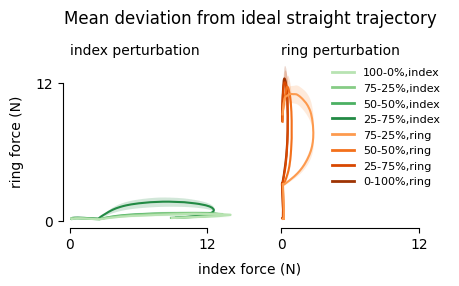

In [9]:
from vis import plot_dev_aligned

fig, axs = plt.subplots(1, 2, figsize=(5, 2.75), sharey=True, sharex=True)
plot_dev_aligned(fig, axs, force, descr)

plt.plot()

rmANOVA index
                 Anova
           F Value Num DF  Den DF Pr > F
----------------------------------------
correspond 17.8907 1.0000 13.0000 0.0010

rmANOVA ring
                 Anova
           F Value Num DF  Den DF Pr > F
----------------------------------------
correspond  6.7472 1.0000 13.0000 0.0221



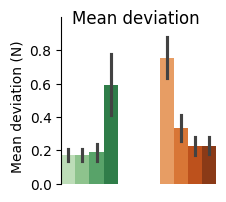

In [10]:
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
fig, axs = plot_force_binned(fig, axs, dat, y=['MD', 'MD'], finger=('index', 'ring'))
axs[0].spines[['left']].set_bounds(0, 1)
axs[0].set_ylabel('Mean deviation (N)')
dat_stat = dat.copy()
dat_stat['correspond'] = 'high'
mask_low = ((dat_stat['cue'] == '75-25%') & (dat_stat['stimFinger'] == 'ring')) | ((dat_stat['cue'] == '25-75%') & (dat_stat['stimFinger'] == 'index'))
dat_stat.loc[mask_low, 'correspond'] = 'low'
dat_stat = dat_stat[dat_stat['GoNogo'] == 'go']

dat_stat = dat_stat.groupby(['sn', 'stimFinger', 'GoNogo','correspond']).mean(numeric_only=True).reset_index()

anova_index = AnovaRM(data=dat_stat[dat_stat['stimFinger']=='index'], depvar='index1', subject='sn', within=['correspond'])
anova_ring = AnovaRM(data=dat_stat[dat_stat['stimFinger']=='ring'], depvar='ring1', subject='sn', within=['correspond'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

fig.suptitle('Mean deviation')

plt.show()

--- AVERAGE FORCE DIFFERENCE ---
0.04704152481899193+/-0.011490299163797355

M1
slope: -0.12653173511040539, p = 0.309
intercept: 0.031146191554357716, p_intercept = 0.001
R2 = 0.086

S1
slope: -0.021014313874710082, p = 0.869
intercept: 0.03726382575972054, p_intercept = 0.001
R2 = 0.002


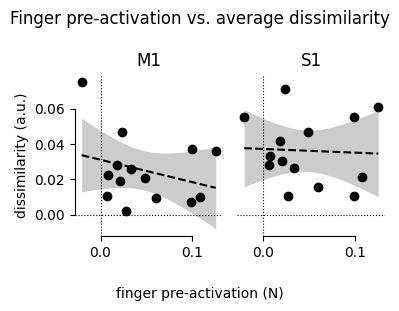

In [14]:
from vis import plot_correlation

rois_tmp = ['M1', 'S1']
sns = [102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115]
diff = np.zeros(len(sns))
pcm_path = os.path.join(gl.baseDir, experiment, gl.pcmDir)
for s, sn in enumerate(sns):
    dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}.dat'), sep='\t')
    dat = dat[(dat['cue']==93) | (dat['cue']==39)]
    diff[s] = dat['forceDiff'].mean()

print('--- AVERAGE FORCE DIFFERENCE ---')
print(f'{diff.mean()}+/-{diff.std() / np.sqrt(len(sns))}')

fig, axs = plt.subplots(1, len(rois_tmp), sharex=True, sharey=True, figsize=(4, 3))

for r, roi in enumerate(rois_tmp):
    print(f'\n{roi}')
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    D = np.array([pcm.G_to_dist(Gg) for Gg in G])
    x = diff
    y = D.mean(axis=(1, 2))
    fig, axs =  plot_correlation(fig, axs, r, x, y, alternative_slope='two-sided', alternative_intercept='two-sided')
    axs[r].set_title(roi)

for ax in axs:
    yticks = ax.get_yticks()
    xticks = ax.get_xticks()
    ax.spines['left'].set_bounds(yticks[1], yticks[-2])
    ax.spines['bottom'].set_bounds(xticks[1], xticks[-2])

axs[0].set_ylabel('dissimilarity (a.u.)', fontsize=10)
axs[1].tick_params('y', left=False)
fig.supxlabel('finger pre-activation (N)', fontsize=10)

fig.suptitle('Finger pre-activation vs. average dissimilarity')

fig.tight_layout()

plt.show()